## Titanic - Machine Learning from Disaster
- build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data
- Dataset Source - https://www.kaggle.com/competitions/titanic/data

  This notebook is for recording what I’ve learned and implemented in my machine learning journey.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../dataset/titanic/train.csv")
df_test = pd.read_csv("../dataset/titanic/test.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

## Data Check

- Missing values
- Data type
- Number of unique values for each feature

In [4]:
df.isna().sum() #missing values: Age, Cabin, Embarked: need to fill missing values or drop column/row

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.nunique() ## There are no duplicates

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [6]:
print("Values in 'Sibsp' variable:",end=" " )
print(df['SibSp'].unique())

print("Values in 'Parch' variable: ",end=" " )
print(df['Parch'].unique())

print("Values in 'Embarked' variable: ",end=" " )
print(df['Embarked'].unique())

Values in 'Sibsp' variable: [1 0 3 4 2 5 8]
Values in 'Parch' variable:  [0 1 2 5 3 4 6]
Values in 'Embarked' variable:  ['S' 'C' 'Q' nan]


## Visualize Data

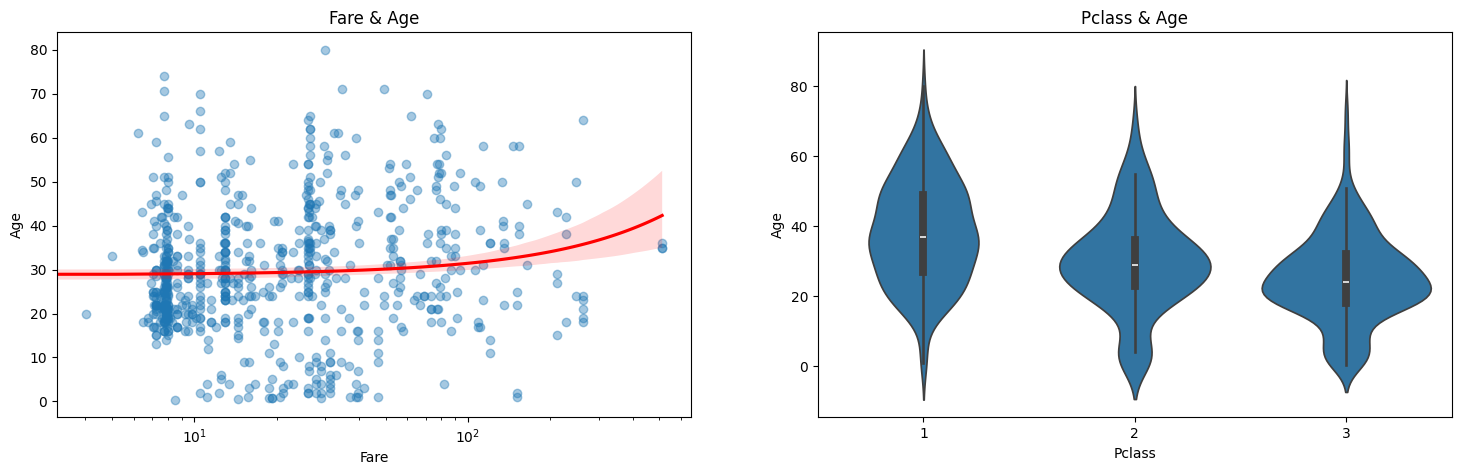

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
sns.regplot(
    data=df,
    x='Fare',
    y='Age',
    ax=axs[0],
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
axs[0].set_xscale('log')
axs[0].set_title('Fare & Age')

sns.violinplot(
    data=df,
    x='Pclass',
    y='Age',
    ax=axs[1]
)
axs[1].set_title('Pclass & Age')
plt.show()


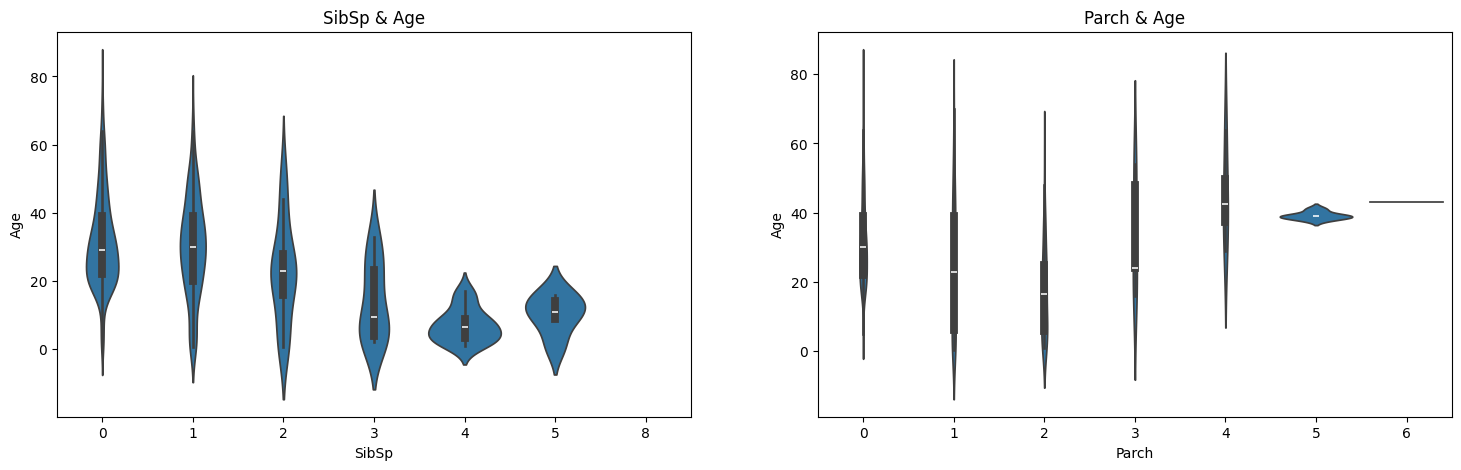

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
sns.violinplot(
    data=df,
    x='SibSp',
    y='Age',
    ax=axs[0]
)
axs[0].set_title('SibSp & Age')

sns.violinplot(
    data=df,
    x='Parch',
    y='Age',
    ax=axs[1]
)
axs[1].set_title('Parch & Age')
plt.show()

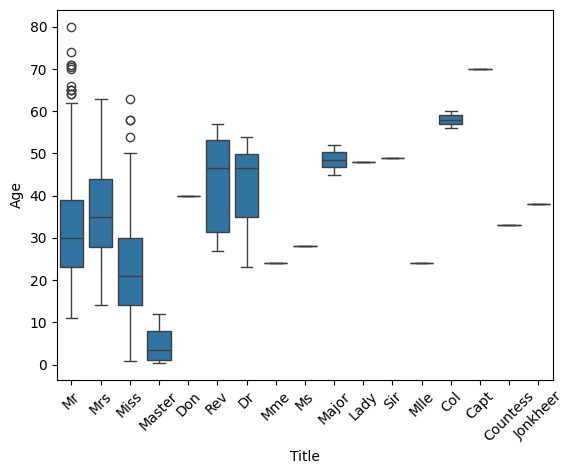

In [9]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
sns.boxplot(data=df, x='Title', y='Age')
plt.xticks(rotation=45)
plt.show()

## Data Processing

In [10]:
#Fill missing Age values using 'Title' and 'Pclass'
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
df['Age'] = df['Age'].fillna(
    df.groupby(['Title', 'Pclass'])['Age'].transform('median')
)

In [11]:
survival_rate = df.groupby('Embarked')['Survived'].mean()
print(survival_rate)

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [12]:
df.dropna(subset=['Embarked'], inplace=True) #Drop record whose Embarked value is missing
df.reset_index(drop=True, inplace=True)

In [13]:
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})  #Change to numerical values

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df[['Embarked']])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Embarked']),
    index=df.index   #important
)

df = pd.concat([df.drop('Embarked', axis=1), encoded_df], axis=1)
df.head()   #Embarked_C means both Embarked_Q, Embarked_S is 0

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,Mr,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,Mrs,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Miss,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,Mrs,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,Mr,0.0,1.0


## Model Training

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split


features_final = ['Pclass','Sex','Age','SibSp','Parch','Embarked_Q','Embarked_S']
X = df[features_final]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [15]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_model(true, predicted, proba=None):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    auc = roc_auc_score(true, proba) if proba is not None else None
    return acc, f1, auc

In [16]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1),
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "XGBoost": XGBClassifier(
        random_state=1,
        eval_metric='logloss',
        use_label_encoder=False
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Prediction
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    train_acc, train_f1, train_auc = evaluate_model(
        y_train, y_train_pred, y_train_proba
    )
    test_acc, test_f1, test_auc = evaluate_model(
        y_test, y_test_pred, y_test_proba
    )

    print(name)
    print("Train")
    print(f"- Accuracy : {train_acc:.4f}")
    print(f"- F1 Score : {train_f1:.4f}")
    print(f"- ROC AUC  : {train_auc:.4f}")

    print("Test")
    print(f"- Accuracy : {test_acc:.4f}")
    print(f"- F1 Score : {test_f1:.4f}")
    print(f"- ROC AUC  : {test_auc:.4f}")
    print("="*20)


Decision Tree
Train
- Accuracy : 0.9367
- F1 Score : 0.9098
- ROC AUC  : 0.9864
Test
- Accuracy : 0.7640
- F1 Score : 0.7000
- ROC AUC  : 0.7689
Random Forest
Train
- Accuracy : 0.9367
- F1 Score : 0.9130
- ROC AUC  : 0.9765
Test
- Accuracy : 0.8202
- F1 Score : 0.7647
- ROC AUC  : 0.8622
AdaBoost
Train
- Accuracy : 0.8200
- F1 Score : 0.7500
- ROC AUC  : 0.8559
Test
- Accuracy : 0.8539
- F1 Score : 0.8169
- ROC AUC  : 0.9169
Gradient Boosting
Train
- Accuracy : 0.8692
- F1 Score : 0.8082
- ROC AUC  : 0.9285
Test
- Accuracy : 0.8315
- F1 Score : 0.7692
- ROC AUC  : 0.9115
XGBoost
Train
- Accuracy : 0.9226
- F1 Score : 0.8911
- ROC AUC  : 0.9688
Test
- Accuracy : 0.8034
- F1 Score : 0.7445
- ROC AUC  : 0.8645


## Apply to Test Data

In [17]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [18]:
"""
from sklearn.preprocessing import OneHotEncoder

df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)
df_test['Title'] = df_test['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
df_test['Age'] = df_test['Age'].fillna(
    df_test.groupby(['Title', 'Pclass'])['Age'].transform('median')
)

df_test.dropna(subset=['Embarked'], inplace=True) #Drop record whose Embarked value is missing
df_test.reset_index(drop=True, inplace=True)

df_test['Sex'] = df_test['Sex'].map({'male': 1, 'female': 0})

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df_test[['Embarked']])
encoded_df_test = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Embarked']),
    index=df_test.index   #important
)
df_test = pd.concat([df_test.drop('Embarked', axis=1), encoded_df_test], axis=1)

# I picked AdaBoost

X_test_final = df_test[features_final]
predictions_final = models["AdaBoost"].predict(X_test_final)

output = pd.DataFrame({'PassengerId': df_test.PassengerId, 'Survived': predictions_final})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")
"""

'\nfrom sklearn.preprocessing import OneHotEncoder\n\ndf_test[\'Title\'] = df_test[\'Name\'].str.extract(\' ([A-Za-z]+)\\.\', expand=False)\ndf_test[\'Title\'] = df_test[\'Title\'].replace(\n    [\'Lady\', \'Countess\', \'Capt\', \'Col\', \'Don\', \'Dr\', \'Major\', \'Rev\', \'Sir\', \'Jonkheer\', \'Dona\'],\n    \'Rare\'\n)\ndf_test[\'Title\'] = df_test[\'Title\'].replace({\'Mlle\':\'Miss\', \'Ms\':\'Miss\', \'Mme\':\'Mrs\'})\ndf_test[\'Age\'] = df_test[\'Age\'].fillna(\n    df_test.groupby([\'Title\', \'Pclass\'])[\'Age\'].transform(\'median\')\n)\n\ndf_test.dropna(subset=[\'Embarked\'], inplace=True) #Drop record whose Embarked value is missing\ndf_test.reset_index(drop=True, inplace=True)\n\ndf_test[\'Sex\'] = df_test[\'Sex\'].map({\'male\': 1, \'female\': 0})\n\nohe = OneHotEncoder(drop=\'first\', sparse_output=False)\nencoded = ohe.fit_transform(df_test[[\'Embarked\']])\nencoded_df_test = pd.DataFrame(\n    encoded,\n    columns=ohe.get_feature_names_out([\'Embarked\']),\n    ind

In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.preprocess import titanic_preprocess
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import pickle

preprocessor = FunctionTransformer(titanic_preprocess)

In [20]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", models["AdaBoost"])
])
pickle.dump(pipeline, open("../models/titanic_pipeline.pkl", "wb"))